#Convolutional Neural Networks
In this notebook, we are going to practice implementing convolutional neural networks in Keras and see how we can use them for image classification.

We'll also see how we can use transfer learning and data augmentation to improve our results.


BTW, since some of you were looking for the motivation behind some of the well known architectures (e.g. ResNet or GoogleNet), I found [this link](https://www.analyticsvidhya.com/blog/2018/12/guide-convolutional-neural-network-cnn/) quite interesting and helpful.

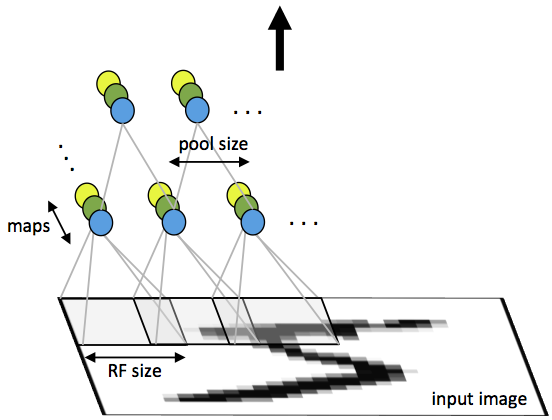

#About the Dataset: CIFAR-10
The CIFAR-10 dataset consists of 60000 32x32 colour images in 10 classes, with 6000 images per class. There are 50000 training images and 10000 test images. The dataset is available [here](https://www.cs.toronto.edu/~kriz/cifar.html). It can also be directly loaded from Keras.

The 10 classes and some sample images are shown below. Our goal would be to develop convolutional neural networks in order to classify each image.

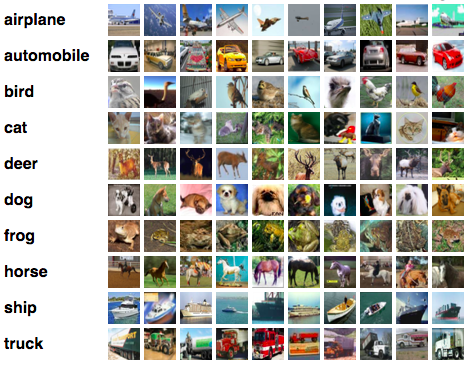

# Installing and Importing Libraries
For the examples we will work on in this notebook, we first need to upgrade the scikit-learn libraries.

Please note that **we will need to restart runtime** after executing the following block.

In [ ]:
# First, let's upgrade scikit-learn package in colab
#!pip uninstall scikit-learn -y
#!pip install -U scikit-learn
import sklearn
#print(sklearn.__version__)

In [ ]:
# Diable warnings about max_itr not reached etc.!
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

Now let's import the libraries we will need later on.

In [ ]:
# Importing necessary libraries
import pandas as pd
import io
import os
import numpy as np
import copy
import pdb
import seaborn as sns #visualisation
import matplotlib.pyplot as plt #visualisation
from keras.models import Sequential
from keras import callbacks
import tensorflow as tf
from sklearn.metrics import f1_score
from tensorflow.keras import initializers
from keras.regularizers import l2,l1,l1_l2

%matplotlib inline
sns.set(color_codes=True)

# Loading the Dataset
CIFAR-10 dataset can be loaded directly from Keras.

In [ ]:
import keras
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

170498071/170498071 [==============================] - 3s 0us/step


In [ ]:
print(X_train.shape)
print(X_test.shape)

(50000, 32, 32, 3)
(10000, 32, 32, 3)


Let's take a look at a few images from the train and test sets:

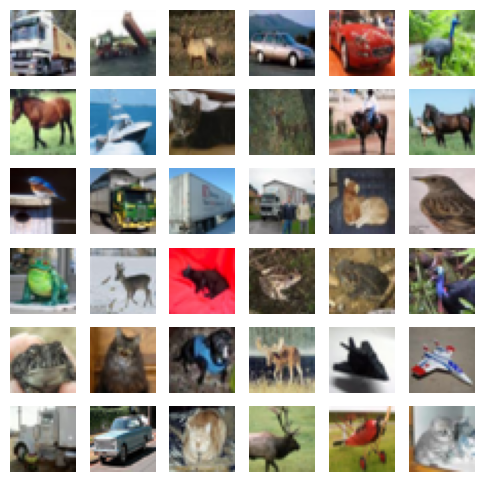

In [ ]:
fig, ax = plt.subplots(nrows=6, ncols=6, figsize=(6,6))
itr = 0
for i in range(0,6):
  for j in range(0,6):
    itr += 1

    # convert to unsigned integers
    image = X_train[itr,:,:,:]

    # plot image
    ax[i,j].imshow(image)
    ax[i,j].axis('off')

# Getting Some Insights from Our Data
It is now time to do some EDA! We just play with different data columns to get more sense about our data.

First, let's check the distribution of classes in the training set:

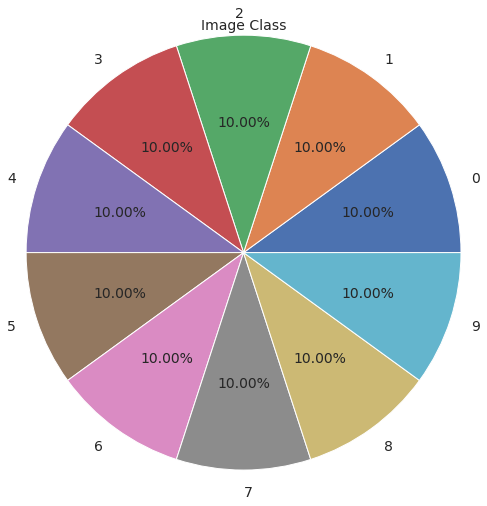

In [ ]:
# Now, let's query the corresponding slice from our main dataframe
y_df = pd.DataFrame(y_train)
selected_labels = range(0,10)
y_df.value_counts().plot(
    kind = 'pie',figsize=(16,8),autopct='%1.2f%%',ylabel='',radius=1.25,labels=selected_labels,fontsize=14)

# Now let's setup the labels, titles and format y axis as percentages
plt.title("Image Class",fontsize=14)
#plt.legend(selected_labels,loc='lower right',fontsize=14)
plt.show()


As we can see from the above chart, data is fully balanced!

# Data Cleaning
Since we are dealing with a dataset of images, we should follow a different approach for cleaning data. For instance we might do some denoising, resizing, padding, etc.

However, CIFAR-10 dataset can be considered "clean" for our purposes. So we move to the next step.

### Normalization/Stadardization
Our next step would be to "normalize" all the columns so that they have a "similar" range. Since we are dealing with images, our feature "columns" are image pixels. So what we need to do is ensure our pixels have a similar range.

As before, we can follow different scaling approaches, e.g. Standard Scaling or MinMax scaling. For now, we proceed with sort-of a MinMax scaling, i.e. dividing all pixels by 255 (Later, we see how we can do StandardScaling (i.e. whitening images) using one of Keras's handy modules)

In [ ]:
X_train = X_train/255.
X_test = X_test/255.

# Pareparing Train and Test Sets
Since we are working with CIFAR-10 dataset, the data is already broken into train and test sets. Nice! :)

Here, since we have three classes, we perform one-hot-encoding on the target variable too. We'll then use the softmax activation function (i.e. similar to what we saw on multinomial regression) to perform multiclass classification.

In [ ]:
# First, let's separate the target column, price
from sklearn.preprocessing import OneHotEncoder,LabelBinarizer
enc = LabelBinarizer()
enc.fit(y_train)

y_train_enc = enc.transform(y_train)

In [ ]:
y_train

array([[6],
       [9],
       [9],
       ...,
       [9],
       [1],
       [1]], dtype=uint8)

In [ ]:
y_train_enc

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 1],
       [0, 0, 0, ..., 0, 0, 1],
       ...,
       [0, 0, 0, ..., 0, 0, 1],
       [0, 1, 0, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 0]])

In [ ]:
y_test_enc = enc.transform(y_test)

# Convultional Networks With Keras
Now it is time to test classification algorithms in action, starting from linear classifiers.

In [ ]:
#Early stopping
early_stopping = callbacks.EarlyStopping(
    min_delta=0.001,          # minimium amount of change to be considered an improvement
    patience=5,              # number of epochs to wait before deciding there is no significant improvement in training
    restore_best_weights=True,
)

### Some Handy Functions
First, let's reuse the wrapper functions we developed in the previous notebook to create models based on given specs. Here, we fix the arcitecture though, for now.

Westart with the function we use to plot the loss or accuracy (precision/recall) of the model during training. The inputs are:


*   history: this is the output history of the keras fit() method
*   plot_type: if it is "loss", the training/validation loss will be plotted. Otherwise, the accuracy graph is returned.



In [ ]:
#@title
def plot_history(history,plot_type: str='loss'):
  hist_df = pd.DataFrame(history.history)
  plt.figure(figsize=(20,8))
  colors = []
  columns_to_plot = []
  labels = []
  for col_name in hist_df.columns:

    # Define colors
    if 'val' in col_name:
      validation = True
      color_base = 'r'
      label_base = 'Validation'
    else:
      validation = False
      color_base = 'b'
      label_base = 'Training'

    if plot_type == 'loss':
      if 'loss' in col_name:
        labels.append(label_base)
        columns_to_plot.append(col_name)
        colors.append(color_base)
    else:
      if 'loss' in col_name:
        continue
      if 'recall' in col_name:
        color = color_base + '--'
        label = label_base + 'Recall'
      else:
        color = color_base
        label = label_base + 'Precision'

      labels.append(label)
      columns_to_plot.append(col_name)
      colors.append(color)



  for itr in range(0,len(columns_to_plot)):
    plt.plot(hist_df.loc[:, [columns_to_plot[itr]]], colors[itr], label=labels[itr],lw=4)

  plt.ylabel(plot_type)
  plt.xlabel('Epochs')
  plt.legend(loc="best")

  plt.show()

Next, we proceed with a function to create a multi-layered feedforward neural network. The way it works is that we specify the following inputs:

*   hidden_layers: specifies the hidden layers and the structure of the network, with the following conventions
    * `Conv2D_AxB_C_D`: a convolutional layer, with the receptive field (kernel size) of size `AxB`, no. filters of `C` and stride of `D`.
    * `MaxPooling2D_AxB_D`: a max pooling layer, with the receptive field (filter) of size `AxB` and stride of `D`
    * `AveragePooling2D_AxB_D`: an average pooling layer, with the receptive field (filter) of size `AxB` and stride of `D`
    * `Flatten`: the flatten layer,
    * `Dense_N`: a dense layer with `N` neurons.
*   input_size: the number of neurons in the input layer. It is equal to `X_train.shape[1]`
*   activation_func: it is a string specifying the type of the activation function.
*   l1_reg: a real number, which specifies the l1-regualirization coefficient in each layer (the higher it is, the more severe the regularization will be).
*   l2_reg: a real number, which specifies the l2-regualirization coefficient in each layer (the higher it is, the more severe the regularization will be).
*   learning_rate: a real number, specifying the learning rate in the gradient descent algorithm
*   learning_rate_decay: a real number, specifying the decay in the learning rate after a few iterations
*   dropout_rate: the rate at which neurons are "dropped-out" during training. If this value is 0, it means we won't have any dropout
*   weight_initializer: name of the weight initialization technique used to setup the weights when the algorithm starts.
    
Once given these inputs, the function creates the model according to our specs, compile it and return it as the output.

In [ ]:
from keras.layers import Dense, Input, Dropout, Conv2D, AveragePooling2D, MaxPooling2D, Flatten

In [ ]:
def create_model(hidden_layers: list=['Conv2D_3x3_10_1','MaxPooling2D_2x2_0','Conv2D_5x5_20_1','AveragePooling2D_2x2_1','Flatten','Dense_30'],
                 input_size=X_train.shape[1:], no_classes= y_train_enc.shape[1], activation_func: str='relu',
                 l1_reg: float=0.0, l2_reg: float=0.0,
                 learning_rate: float=0.001, learning_rate_decay: float=0.95,
                 dropout_rate: float=0.0,weight_initializer: str='',
                 optimizer_name: str='adam',regularization_type: str='kernel_regularizer',
                 ):

  # Setup the weight initialization techniques
  if weight_initializer == 'RandomNormal':
    weight_initializer = 'initializers.RandomNormal()'
  elif weight_initializer == 'RandomUniform':
    weight_initializer = 'initializers.RandomUniform()'
  elif weight_initializer == 'Zeros':
    weight_initializer = 'initializers.Zeros()'
  elif weight_initializer == 'GlorotUniform':
    weight_initializer = 'initializers.GlorotUniform()'
  elif weight_initializer == 'GlorotNormal':
    weight_initializer = 'initializers.GlorotNormal()'
  else:
    weight_initializer = 'None'

  model = Sequential()

  model.add(Input(shape=input_size))
  # Add hidden layers
  itr = 0
  for layer in hidden_layers:

      # Determine layer type
      layer_specs = layer.split('_')
      layer_type = layer_specs[0]
      eval_string = 'model.add('
      if layer_type == 'Dense':
        n_l = layer_specs[1]
        eval_string += 'Dense(%s,' %n_l
      elif layer_type == 'Flatten':
        eval_string += 'Flatten('
      elif layer_type == 'Conv2D':
        kernel_size = layer_specs[1]
        filters = layer_specs[2]
        stride = layer_specs[3]
        if not stride or stride == '0':
          stride = 'None'
        eval_string += 'Conv2D(kernel_size=(%s,%s),strides=%s,filters=%s,' %(kernel_size.split('x')[0],kernel_size.split('x')[1],stride,filters)
      elif 'pool' in layer_type.lower():
        pool_size = layer_specs[1]
        stride = layer_specs[2]
        if not stride or stride == '0':
          stride = 'None'
        eval_string += '%s(pool_size=(%s,%s),strides=%s,' %(layer_type,pool_size.split('x')[0],pool_size.split('x')[1],stride)

      if 'pool' not in layer_type.lower() and 'flatten' not in layer_type.lower():
        eval_string += 'activation="%s",' %activation_func
        eval_string += 'kernel_initializer=%s,' %weight_initializer

        if l1_reg and l2_reg:
          eval_string += '%s=l1_l2(%f,%f),' %(regularization_type,l1_reg,l2_reg)
        elif l1_reg:
          eval_string += '%s=l1(%f),' %(regularization_type,l1_reg)
        elif l2_reg:
          eval_string += '%s=l1(%f),' %(regularization_type,l1_reg)

      eval_string += '))'

      # Add regularization
      if 1:
        eval(eval_string)
      else:
        pdb.set_trace()



      itr += 1

  # Add the last layer's activation layer
  if dropout_rate:
      model.add(Dropout(dropout_rate))
  model.add(Dense(no_classes, activation='softmax'))

  # Next, let's compile it
  if optimizer_name == 'sgd':
    opimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)
  elif optimizer_name == 'RMSprop':
    opimizer = tf.keras.optimizers.RMSprop(learning_rate=learning_rate)
  elif optimizer_name == 'Adadelta':
    opimizer = tf.keras.optimizers.Adadelta(learning_rate=learning_rate,rho=learning_rate_decay)
  else:
    opimizer = tf.keras.optimizers.Adam(lr=learning_rate,beta_1=learning_rate_decay)
  model.compile(
        loss='categorical_crossentropy',
        optimizer=opimizer,
        metrics=['accuracy'],
        )

  return model

### What were the important parameters to consider for a convolutional layer?
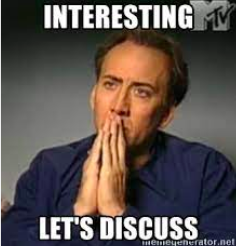






### Building the Model
So a simple model would be built like this.

In [ ]:
model = create_model(activation_func='sigmoid',l1_reg=0,l2_reg=0)
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 30, 30, 10)        280       
                                                                 
 max_pooling2d (MaxPooling2  (None, 15, 15, 10)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 11, 11, 20)        5020      
                                                                 
 average_pooling2d (Average  (None, 10, 10, 20)        0         
 Pooling2D)                                                      
                                                                 
 flatten (Flatten)           (None, 2000)              0         
                                                                 
 dense (Dense)               (None, 30)                6

Voila! The model is successfully built. Let's train it!

In [ ]:
history = model.fit(X_train, y_train_enc,
                    batch_size = 16,
                    epochs = 15,
                    validation_split=0.2,
                    callbacks=[early_stopping]
                    )

Epoch 1/15
2500/2500 [==============================] - 51s 20ms/step - loss: 2.0379 - accuracy: 0.2505 - val_loss: 1.8843 - val_accuracy: 0.3182
Epoch 2/15
2500/2500 [==============================] - 57s 23ms/step - loss: 1.7483 - accuracy: 0.3697 - val_loss: 1.6765 - val_accuracy: 0.3961
Epoch 3/15
2500/2500 [==============================] - 44s 18ms/step - loss: 1.6132 - accuracy: 0.4146 - val_loss: 1.5696 - val_accuracy: 0.4292
Epoch 4/15
2500/2500 [==============================] - 47s 19ms/step - loss: 1.5181 - accuracy: 0.4529 - val_loss: 1.4956 - val_accuracy: 0.4572
Epoch 5/15
2500/2500 [==============================] - 47s 19ms/step - loss: 1.4572 - accuracy: 0.4745 - val_loss: 1.4871 - val_accuracy: 0.4668
Epoch 6/15
2500/2500 [==============================] - 72s 29ms/step - loss: 1.4158 - accuracy: 0.4911 - val_loss: 1.4866 - val_accuracy: 0.4667
Epoch 7/15
2500/2500 [==============================] - 48s 19ms/step - loss: 1.3803 - accuracy: 0.5051 - val_loss: 1.4095 -

Let's see the progress of our algorithm in each iteration:

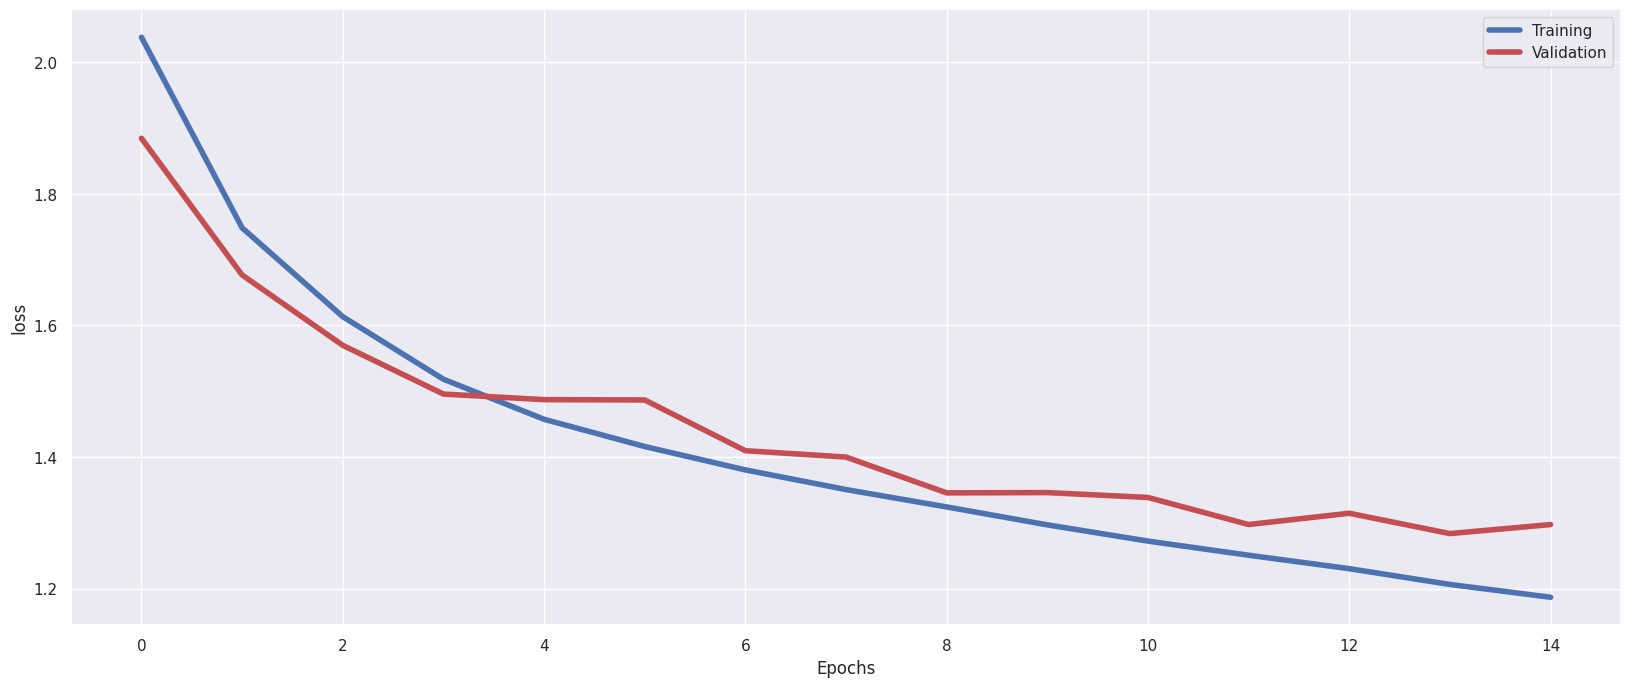

In [ ]:
plot_history(history,plot_type='loss')

Now let's evaluate the performance of our algorithm on the test set

In [ ]:
def convert_predictions(predictions):
  output = np.argmax(predictions,axis=1)
  return output

In [ ]:
predictions = model.predict(X_test)

313/313 [==============================] - 3s 9ms/step


In [ ]:
print('Weighted F1-score is %.2f' %f1_score(y_test, convert_predictions(predictions), average='weighted'))

Weighted F1-score is 0.55


Also, let's calculate top-3 accuracy

In [ ]:
from sklearn.metrics import top_k_accuracy_score

In [ ]:
print('Top-3 accuracy %.2f' %top_k_accuracy_score(y_test, predictions, k=3))

Top-3 accuracy 0.84


Finally, let's see the confusion matrix to see how we are performing with respect to each class.

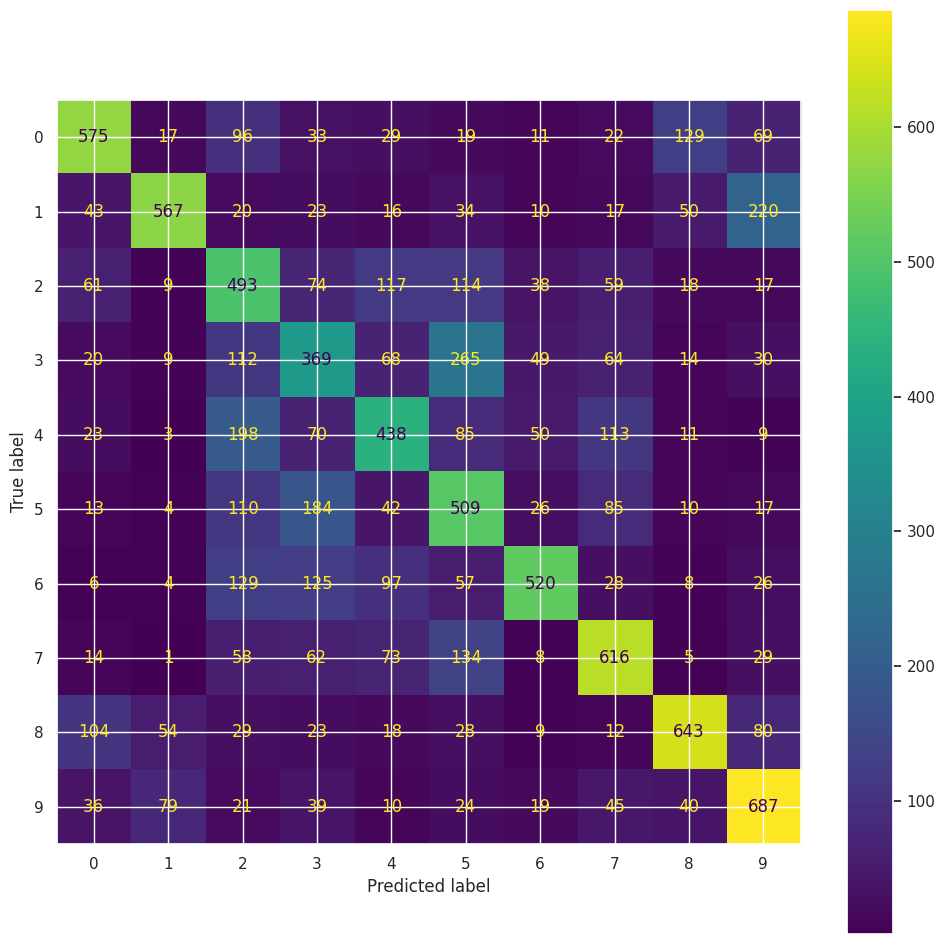

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
fig, ax = plt.subplots(figsize=(12, 12))
ConfusionMatrixDisplay.from_predictions(y_test, convert_predictions(predictions),ax=ax)
plt.show()

# Investigate the Effects of Different Parameters

*   Kernel Size
*   Receptive field size
*   Srtide
*   Type of Pooling
*   Activation functions
*   Weight Initialization


### <font color="blue">K-Fold Cross Validation
So far, we have seen the performance of the algorithm over the test set. But depending on the split, we might get lucky/unlucky and overestimate/underestimate the accuracy.

To resolve this issue, we will do k-fold cross validation, to be more sure about the performance of our algorithm.


In [ ]:
from sklearn.model_selection import KFold#, StratifiedKFold

To make things easier and allowing code recycling, we create a similar wrapper-function for k-fold cross validation and use it throughout this notebook. The inputs are:


*   no_folds: the number of folds we are going to use
*   plot_results: if True, the progress of training procedure is displayed and the resulting loss/accuracy is going to be dispayed after each fold is done.
*   models_params: this is the dictionry of the parameters we need to pass to the create_model() function above
*   training_params: these are the parameters used to tune the training algorithm

Once the inputs are specified, the function loops over the specified number of folds, and return the average and standard deviation of the accuracy over the validation set.



In [ ]:
def kfold_validation(no_folds: int=3, plot_results: bool=True,
                     model_params: dict={},training_params: dict={}):
  validation_set_accuracy = []
  models = []

  if plot_results:
    verbose=2
  else:
    verbose=0

  itr = 0
  kf = KFold(n_splits=no_folds)
  for train_index, val_index in kf.split(X_train,y_train):
    train_set, y_train_set = X_train[train_index,:,:,:], y_train_enc[train_index]
    val_set,y_val = X_train[val_index,:,:,:], y_train_enc[val_index]

    # First, create a new model
    model = create_model(**model_params)
    #model.summary()

    # Finally, let's fit the model
    history = model.fit(train_set, y_train_set,
                      validation_data=(val_set,y_val),
                      callbacks=[early_stopping],
                      verbose=verbose,
                      **training_params,
                      )


    # Finally, let's
    pred_val = model.predict(val_set)
    f1 = f1_score(convert_predictions(y_val), convert_predictions(pred_val), average='weighted')

    validation_set_accuracy.append(f1)
    models.append(model)

    # Plot the results
    if plot_results:
      plot_history(history,plot_type='acc')


  # Convert to numpy array
  validation_set_accuracy = np.array(validation_set_accuracy)

  # Return the best model (as an example)
  ind = np.argmax(validation_set_accuracy)
  best_model = models[ind]

  # Delete remaining models
  models.remove(best_model)
  for m in models:
    del m

  # Print the reults
  if plot_results:
    print('Average F1-Score over validation set is %.2f' %validation_set_accuracy.mean())
    print('STD of F1-Score over validation set is %.2f' %validation_set_accuracy.std())
  return best_model,validation_set_accuracy.mean(),validation_set_accuracy.std()

Let's also reuse the function we used to evaluate the effect of different parameters from our last lab session.

In [ ]:
def evaluate_efect_param(parameter_type: str='kfold', parameter_name: str='', values_list: list=[]):
  scores_val = []
  scores_test = []
  models = []
  for val in values_list:

      if parameter_type == 'kfold':
        kfold_params[parameter_name] = val
      elif parameter_type == 'model_params':
        kfold_params['model_params'][parameter_name] = val
      elif parameter_type == 'training_params':
        kfold_params['training_params'][parameter_name] = val

      model,validation_set_accuracy_mean,validation_set_accuracy_std = kfold_validation(**kfold_params)

      scores_val.append(validation_set_accuracy_mean)

      predictions = model.predict(X_test)
      score_test = f1_score(convert_predictions(y_test), convert_predictions(predictions), average='weighted')
      scores_test.append(score_test)

      models.append(model)
      print('Val: %s, Validation Score: %.3f, Test Score: %.3f' %(str(val),validation_set_accuracy_mean,score_test))


  # Plot the results
  plt.figure(figsize=(20,8))
  str_values_list = []
  for v in values_list:
    str_values_list.append(str(v))

  plt.plot(str_values_list,scores_test,lw=5)
  plt.plot(str_values_list,scores_val,lw=5,color='orange')
  plt.xlabel(parameter_name)
  plt.ylabel('F1-Score')
  plt.legend(['F1: Test Set','F1: Validation Set'])
  plt.show()

  # Get the best model
  ind = np.argmax(scores_val)
  best_model = models[ind]

  best_val = values_list[np.argmax(scores_val)]

  # Delete remaining models
  models.remove(best_model)
  for m in models:
    del m

  return best_model,best_val


In [ ]:
kfold_params = {
    'no_folds': 3,
    'plot_results': False,
    'model_params': {
      'hidden_layers': ['Conv2D_3x3_10_1','MaxPooling2D_2x2_0','Conv2D_5x5_20_1','AveragePooling2D_2x2_1','Flatten','Dense_30'],
      'activation_func': 'relu',
      'l1_reg': 0,
      'l2_reg': 0,
      'learning_rate': 0.001,
      'learning_rate_decay': 0.9,
      'dropout_rate':0.01,
      'weight_initializer': 'GlorotNormal',
      'optimizer_name': 'adam',
      'regularization_type': 'kernel_regularizer',
  },
  'training_params': {
    'batch_size': 32,
    'epochs': 5
  }
}

In [ ]:
model,validation_set_accuracy_mean,validation_set_accuracy_std = kfold_validation(**kfold_params)

521/521 [==============================] - 6s 10ms/step


521/521 [==============================] - 6s 11ms/step


521/521 [==============================] - 7s 14ms/step


In [ ]:
print(validation_set_accuracy_mean,validation_set_accuracy_std)

0.5705175241022971 0.016274891475695736


In [ ]:
kfold_params['plot_results'] = False

### <font color="blue">Effect of Learning Rate
Now that we have tested the performance of the algorithm more thoroughly using k-fold cross validation, let's explore the effect of other parameters, starting with the learning rate.

521/521 [==============================] - 6s 12ms/step


521/521 [==============================] - 7s 12ms/step


313/313 [==============================] - 3s 9ms/step
Val: 0.0001, Validation Score: 0.599, Test Score: 0.204


521/521 [==============================] - 7s 12ms/step


521/521 [==============================] - 7s 13ms/step


313/313 [==============================] - 3s 11ms/step
Val: 0.001, Validation Score: 0.596, Test Score: 0.115


521/521 [==============================] - 6s 11ms/step


521/521 [==============================] - 5s 10ms/step


313/313 [==============================] - 3s 10ms/step
Val: 0.01, Validation Score: 0.581, Test Score: 0.145


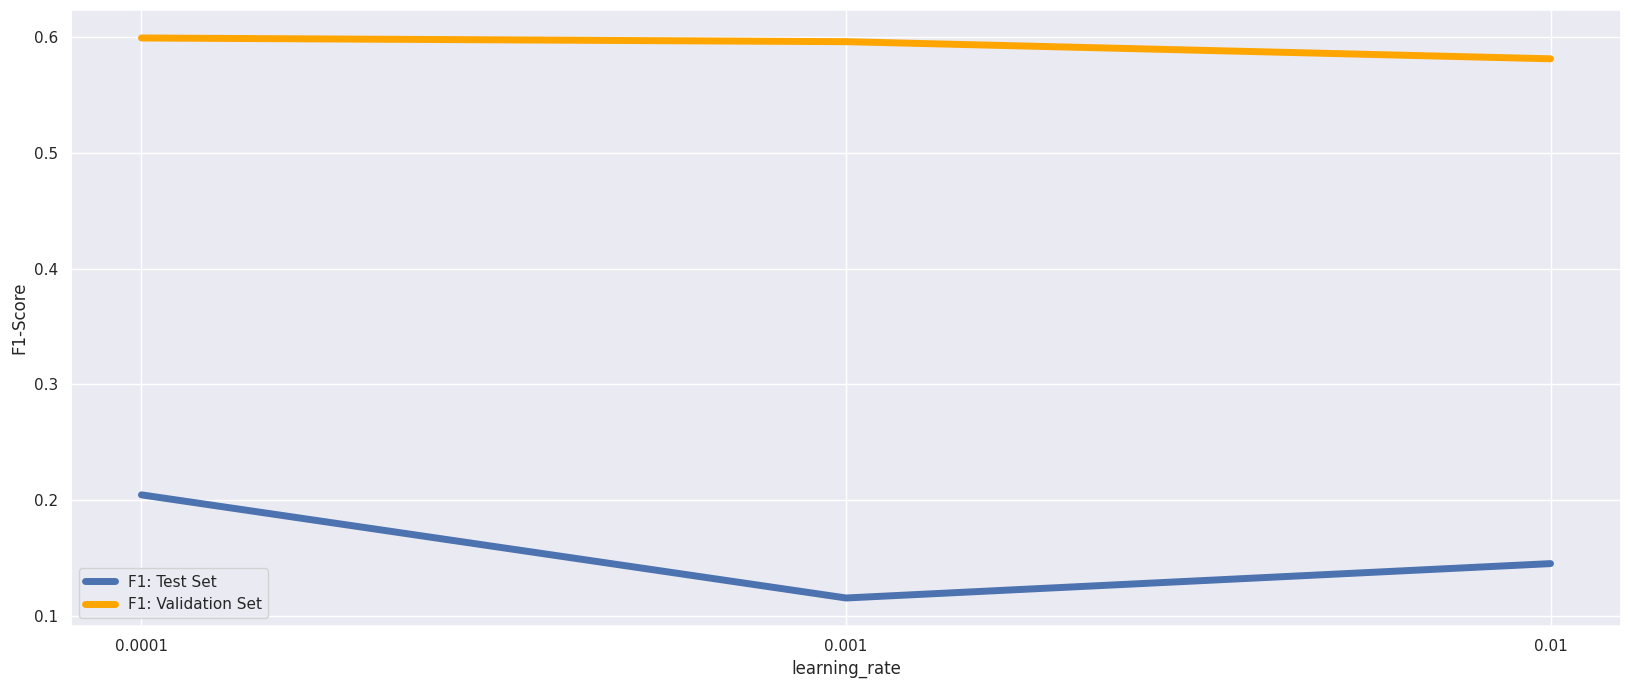

In [ ]:
model,best_lr = evaluate_efect_param(parameter_type='model_params',parameter_name='learning_rate', values_list=[0.0001,0.001,.01])
kfold_params['model_params']['learning_rate'] = best_lr

### <font color="blue"> Effect of Learning Rate Decay
Another factor that could affect the speed of learning, as well as convergence, is the rate at which learning rate is decayed, i.e. after a few iterations, the algorithm can reduce learning rate in the hope not to miss the (local) minimum.

313/313 [==============================] - 3s 9ms/step
Val: 0.75, Validation Score: 0.576, Test Score: 0.180
313/313 [==============================] - 3s 10ms/step
Val: 0.85, Validation Score: 0.567, Test Score: 0.221
313/313 [==============================] - 3s 9ms/step
Val: 0.95, Validation Score: 0.592, Test Score: 0.212


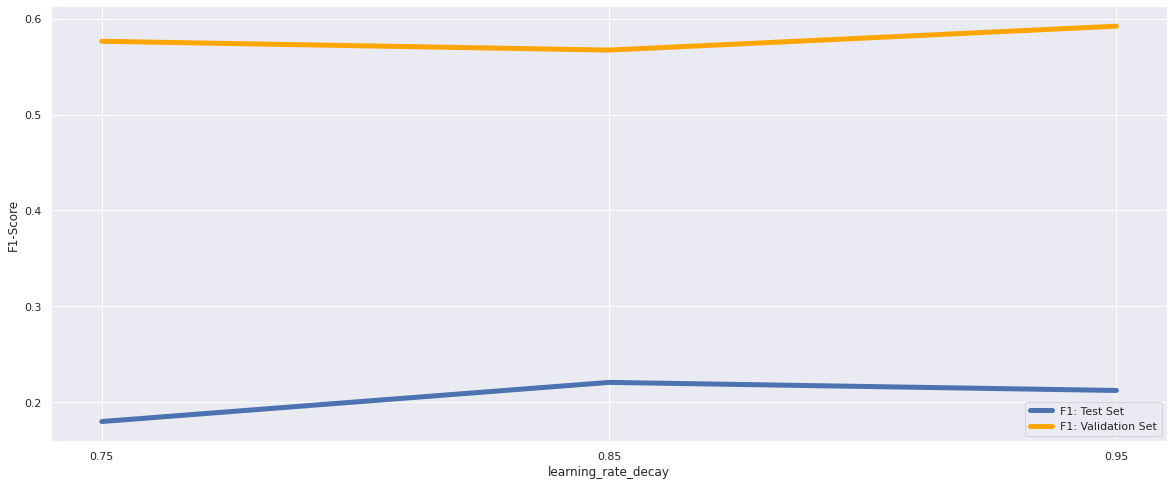

In [ ]:
model,best_lr_decay = evaluate_efect_param(parameter_type='model_params',parameter_name='learning_rate_decay', values_list=[0.75,0.85,0.95])
kfold_params['model_params']['learning_rate_decay'] = best_lr_decay

When the decay is too high (the rate is low), we get worse results, because the learning rate drops too fast, which means the learning will be slow and the algorithm underperforms.

On the other hand, if there is no decay or decay is very low, the algorithm might pass the optimum point and we get a worse result again. So this is something we need to tune as well.

### <font color="blue">Effect of Optimizer
There are multiple opitmizers we can use in the training algorithm. For a complete list, please check [this link](https://keras.io/api/optimizers/).

Let's see if they have any effect on the performance.

313/313 [==============================] - 3s 10ms/step
Val: sgd, Validation Score: 0.283, Test Score: 0.132
313/313 [==============================] - 3s 9ms/step
Val: adam, Validation Score: 0.594, Test Score: 0.177
313/313 [==============================] - 3s 9ms/step
Val: RMSprop, Validation Score: 0.586, Test Score: 0.180
313/313 [==============================] - 3s 9ms/step
Val: Adadelta, Validation Score: 0.087, Test Score: 0.658


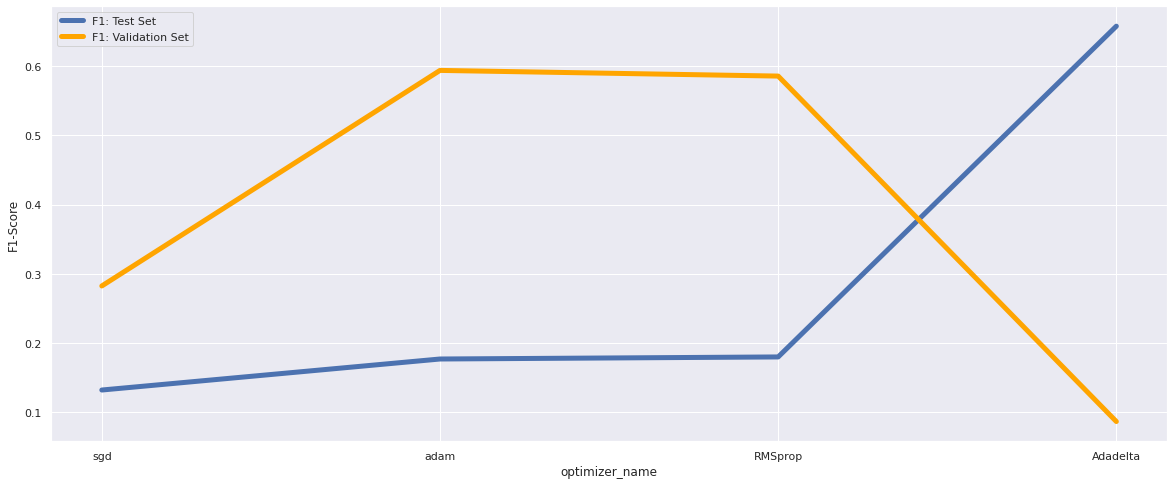

In [ ]:
model,best_optimizer = evaluate_efect_param(parameter_type='model_params',parameter_name='optimizer_name', values_list=['sgd','adam','RMSprop','Adadelta'])
kfold_params['model_params']['optimizer_name'] = best_optimizer

### <font color="blue">Effect of Activation Functions
With the weights setup, we can also experiment with the activation functions. Some of the functions we have seen in the class. Some others are provided below as well.

For a complete list of activation functions available in Keras, please check [this link](https://keras.io/api/layers/activations/).

313/313 [==============================] - 3s 9ms/step
Val: relu, Validation Score: 0.578, Test Score: 0.169
313/313 [==============================] - 3s 10ms/step
Val: tanh, Validation Score: 0.557, Test Score: 0.189
313/313 [==============================] - 3s 10ms/step
Val: sigmoid, Validation Score: 0.403, Test Score: 0.200
313/313 [==============================] - 3s 11ms/step
Val: softplus, Validation Score: 0.439, Test Score: 0.163
313/313 [==============================] - 3s 9ms/step
Val: softsign, Validation Score: 0.544, Test Score: 0.210
313/313 [==============================] - 3s 10ms/step
Val: selu, Validation Score: 0.573, Test Score: 0.195


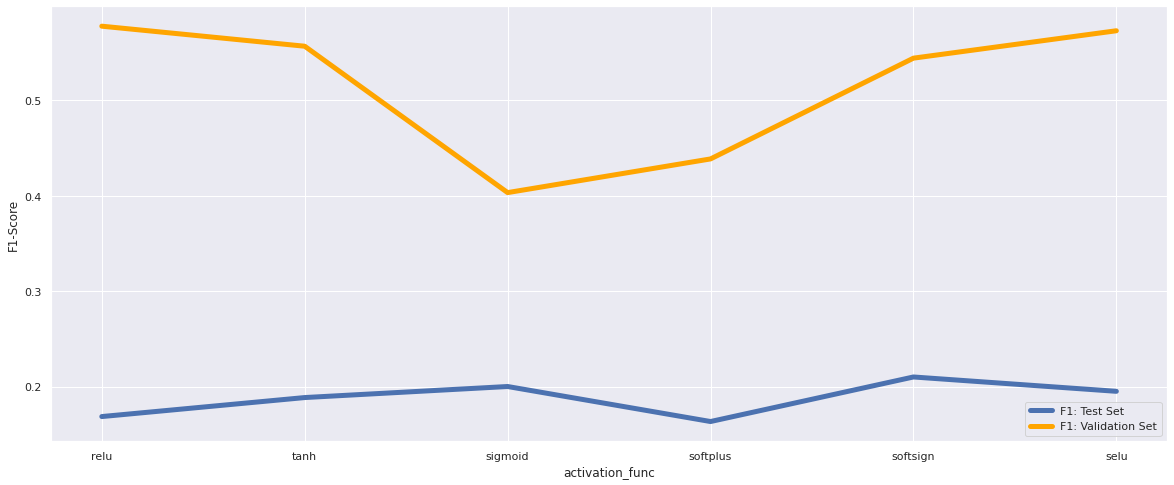

In [ ]:
model,best_activation_func = evaluate_efect_param(parameter_type='model_params',parameter_name='activation_func', values_list=['relu','tanh','sigmoid','softplus','softsign','selu'])
kfold_params['model_params']['activation_func'] = best_activation_func

### <font color="blue"> Effect of Weight Initialization Techniques
In the lecture, we saw that the way wieghts are initialized has a crucial impact on the training process, especially when "sigmoid" or "tanh" activation functions are used.

So let's explore some of the options we have and check their effect on the performance of the algorithm. For a complete list of weight initialization methods available in Keras, check [this link](https://keras.io/api/layers/initializers/).

313/313 [==============================] - 3s 10ms/step
Val: RandomNormal, Validation Score: 0.560, Test Score: 0.202
313/313 [==============================] - 3s 9ms/step
Val: RandomUniform, Validation Score: 0.499, Test Score: 0.141
313/313 [==============================] - 3s 9ms/step
Val: Zeros, Validation Score: 0.017, Test Score: 0.000
313/313 [==============================] - 3s 10ms/step
Val: GlorotUniform, Validation Score: 0.581, Test Score: 0.162
313/313 [==============================] - 3s 9ms/step
Val: GlorotNormal, Validation Score: 0.549, Test Score: 0.110


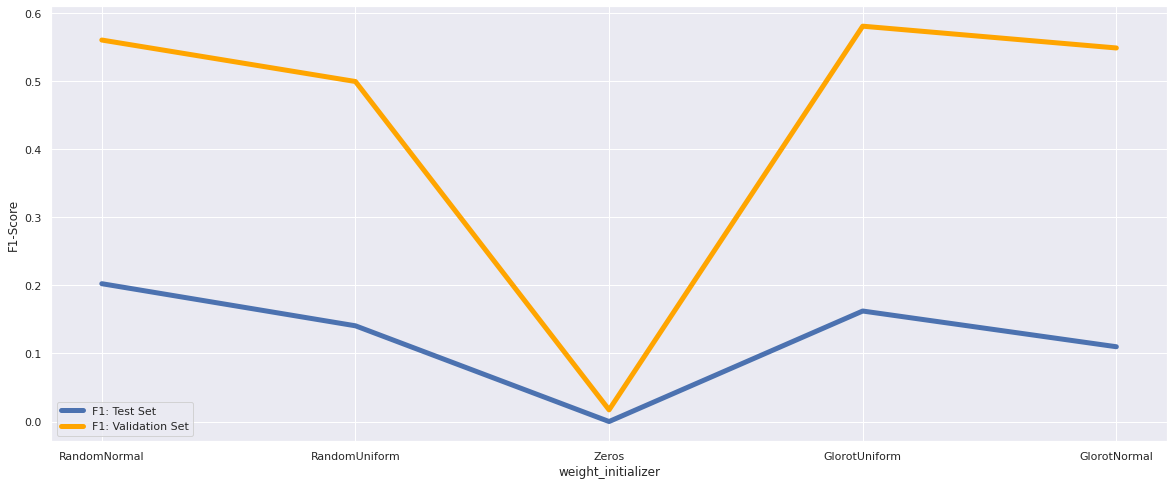

In [ ]:
weight_initializers=['RandomNormal','RandomUniform','Zeros','GlorotUniform','GlorotNormal']
model,best_weight_initializer = evaluate_efect_param(parameter_type='model_params',parameter_name='weight_initializer', values_list=weight_initializers)
kfold_params['model_params']['weight_initializer'] = best_weight_initializer

### <font color="blue">Effect of Dropout
Dropout is the process of ignoring some neuron randomly during each training epoch. In principle, it should add robustness to our algorithm, as it forces neurons to learn features that are not just specific to the training set. Let's see how they work in practice.


313/313 [==============================] - 3s 10ms/step
Val: 0.0001, Validation Score: 0.589, Test Score: 0.212
313/313 [==============================] - 3s 10ms/step
Val: 0.01, Validation Score: 0.564, Test Score: 0.154
313/313 [==============================] - 3s 9ms/step
Val: 0.1, Validation Score: 0.555, Test Score: 0.181
313/313 [==============================] - 3s 9ms/step
Val: 0.3, Validation Score: 0.530, Test Score: 0.217


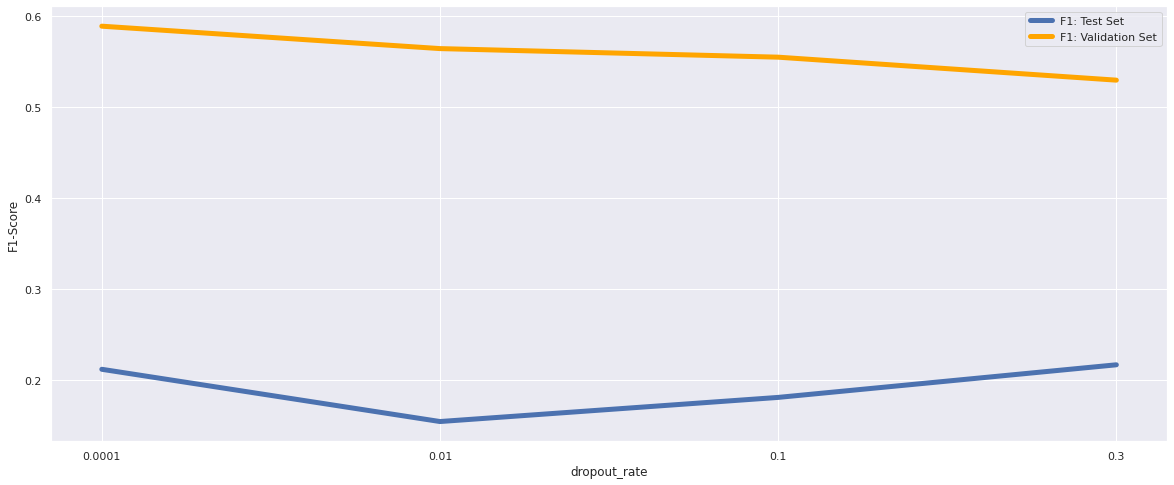

In [ ]:
model,best_dropout_rate = evaluate_efect_param(parameter_type='model_params',parameter_name='dropout_rate', values_list=[0.0001,0.01,0.1,0.3])
kfold_params['model_params']['dropout_rate'] = best_dropout_rate

### <font color="blue">Effect of L1 and L2 Regularization
We saw in earlier sessions that regularization has an important role in preventing overfitting. Therefore, it would be interesting to see how they affect the performance of our neural network.

There are three main types of reguliarizers [available in Keras](https://keras.io/api/layers/regularizers/) layers:


*   kernel_regularizer: applies regularization penalty to the weights
*   activity_regularizer: regularizes the *output* neurons of a layer, in order to keep their value bounded (similar to normalizing te output)
*   bias_regularizer: applies regularization to the bias (i.e. the contant threshold) in neurons. The higher bias_regularizer is, the closer the bias would be to zero.



In [ ]:
model,best_l1_reg = evaluate_efect_param(parameter_type='model_params',parameter_name='l1_reg', values_list=[0.00001,0.0001,0.001,0.01])
kfold_params['model_params']['l1_reg'] = best_l1_reg

Likewise, we can test effects of L2-regularization:

313/313 [==============================] - 3s 10ms/step
Val: 1e-05, Validation Score: 0.579, Test Score: 0.149
313/313 [==============================] - 3s 10ms/step
Val: 0.0001, Validation Score: 0.588, Test Score: 0.162
313/313 [==============================] - 3s 10ms/step
Val: 0.001, Validation Score: 0.586, Test Score: 0.175
313/313 [==============================] - 3s 9ms/step
Val: 0.01, Validation Score: 0.584, Test Score: 0.132


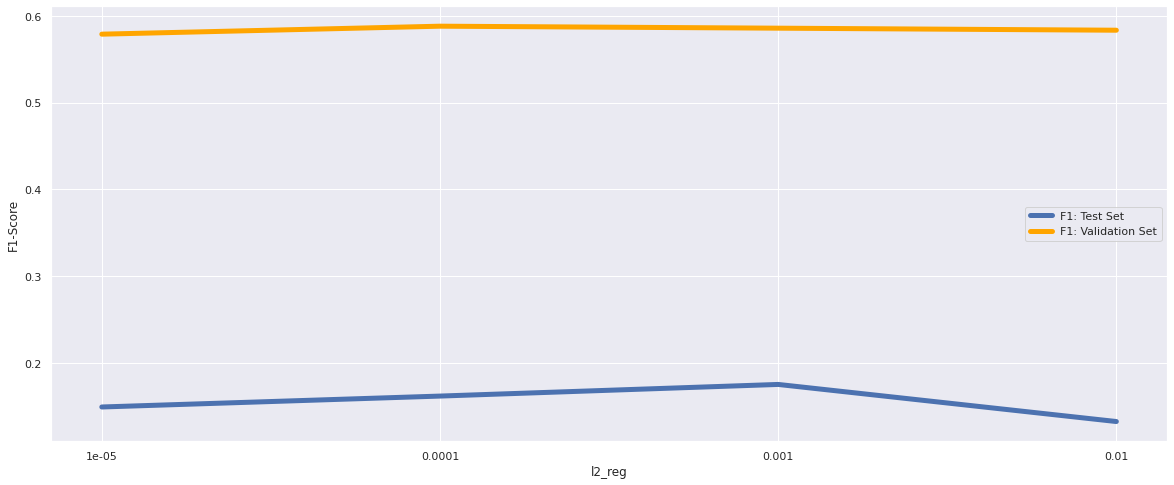

In [ ]:
model,best_l2_reg = evaluate_efect_param(parameter_type='model_params',parameter_name='l2_reg', values_list=[0.00001,0.0001,0.001,0.01])
kfold_params['model_params']['l2_reg'] = best_l2_reg

Let's also check the effect of regularization on the activation functions

313/313 [==============================] - 3s 10ms/step
Val: 1e-05, Validation Score: 0.596, Test Score: 0.203
313/313 [==============================] - 3s 9ms/step
Val: 0.0001, Validation Score: 0.605, Test Score: 0.194
313/313 [==============================] - 3s 10ms/step
Val: 0.001, Validation Score: 0.386, Test Score: 0.225
313/313 [==============================] - 3s 9ms/step
Val: 0.01, Validation Score: 0.017, Test Score: 0.000


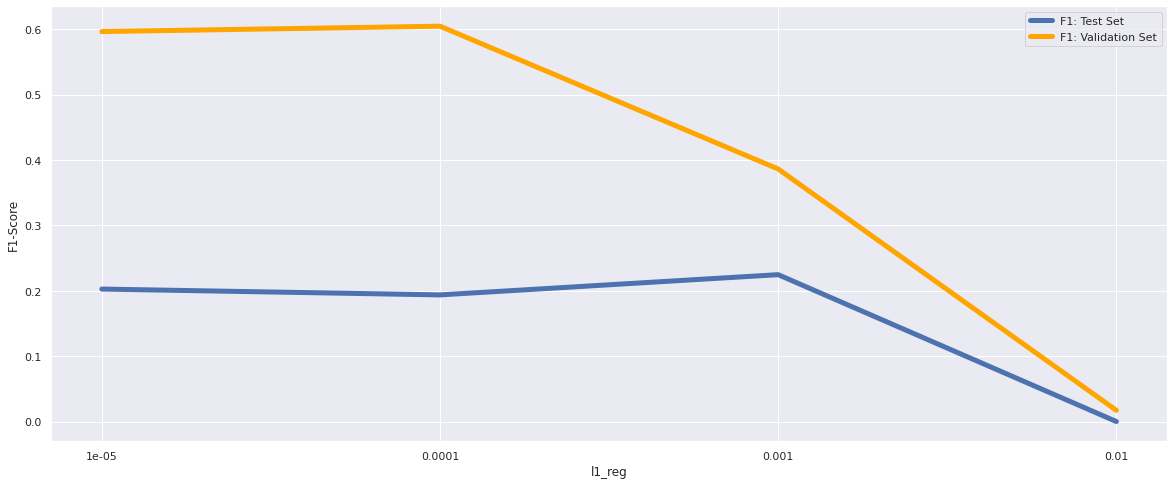

In [ ]:
kfold_params['model_params']['regularization_type'] = 'activity_regularizer'
model,best_l1_reg = evaluate_efect_param(parameter_type='model_params',parameter_name='l1_reg', values_list=[0.00001,0.0001,0.001,0.01])
kfold_params['model_params']['l1_reg'] = best_l1_reg

313/313 [==============================] - 3s 9ms/step
Val: 1e-05, Validation Score: 0.593, Test Score: 0.187
313/313 [==============================] - 3s 9ms/step
Val: 0.0001, Validation Score: 0.609, Test Score: 0.205
313/313 [==============================] - 3s 10ms/step
Val: 0.001, Validation Score: 0.594, Test Score: 0.219
313/313 [==============================] - 3s 10ms/step
Val: 0.01, Validation Score: 0.580, Test Score: 0.185


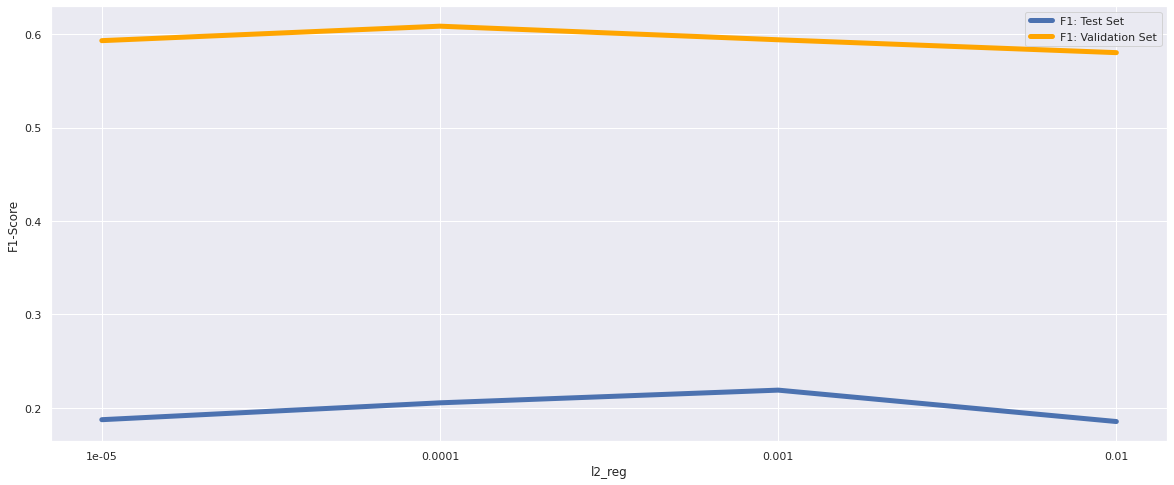

In [ ]:
model,best_l2_reg = evaluate_efect_param(parameter_type='model_params',parameter_name='l2_reg', values_list=[0.00001,0.0001,0.001,0.01])
kfold_params['model_params']['l2_reg'] = best_l2_reg

## How about a Different Architecture?
So far, we have kept the structure of network intact. What if we add more layers, with different number of neurons? will that affect the performance?


### <font color="blue">Effect of Receptive Field Size
Let's start with a network with a different receptive field sizes size

### What is your educated guess about the effect of receptive field size on performance?
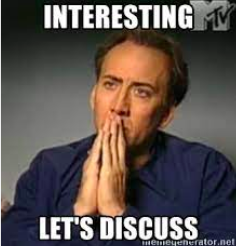






313/313 [==============================] - 2s 8ms/step
Val: ['Conv2D_3x3_10_1', 'MaxPooling2D_2x2_0', 'Conv2D_3x3_20_1', 'MaxPooling2D_2x2_0', 'Flatten', 'Dense_30'], Validation Score: 0.559, Test Score: 0.174
313/313 [==============================] - 3s 9ms/step
Val: ['Conv2D_5x5_10_1', 'MaxPooling2D_2x2_0', 'Conv2D_5x5_20_1', 'MaxPooling2D_2x2_0', 'Flatten', 'Dense_30'], Validation Score: 0.539, Test Score: 0.149
313/313 [==============================] - 3s 10ms/step
Val: ['Conv2D_7x7_10_1', 'MaxPooling2D_2x2_0', 'Conv2D_7x7_20_1', 'MaxPooling2D_2x2_0', 'Flatten', 'Dense_30'], Validation Score: 0.490, Test Score: 0.150


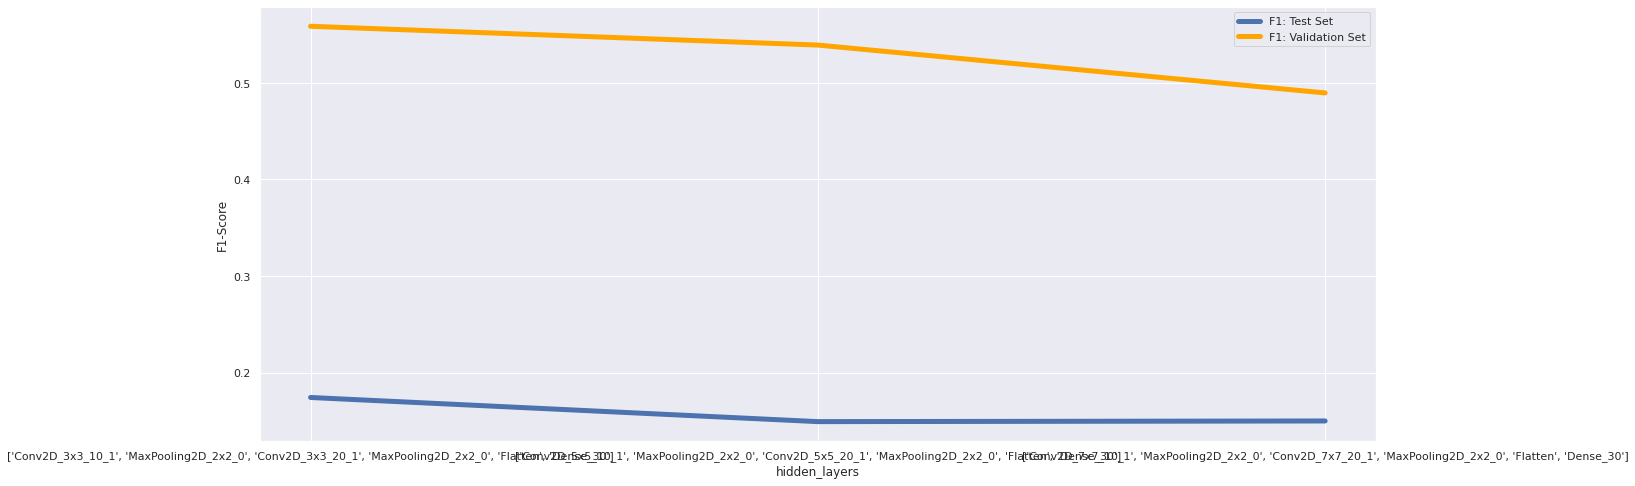

In [ ]:
# Kernel size of 3
values_list = [['Conv2D_3x3_10_1','MaxPooling2D_2x2_0','Conv2D_3x3_20_1','MaxPooling2D_2x2_0','Flatten','Dense_30']]


# Kernel size of 5
values_list += [['Conv2D_5x5_10_1','MaxPooling2D_2x2_0','Conv2D_5x5_20_1','MaxPooling2D_2x2_0','Flatten','Dense_30']]

# Kernel size of 7
values_list += [['Conv2D_7x7_10_1','MaxPooling2D_2x2_0','Conv2D_7x7_20_1','MaxPooling2D_2x2_0','Flatten','Dense_30']]

model,best_architecture = evaluate_efect_param(parameter_type='model_params',parameter_name='hidden_layers',values_list=values_list)
kfold_params['model_params']['hidden_layers'] = best_architecture

### <font color="blue">Effect Convolution Stride
Next, let's see what the best stride is. We keep the receptive field size to 5

### What effects do you think the stride will have on the performance?
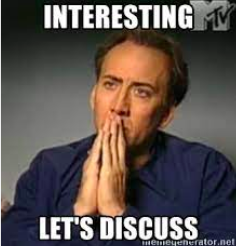






In [ ]:
# Stride 1
values_list = [['Conv2D_5x5_10_1','MaxPooling2D_2x2_0','Conv2D_5x5_20_1','MaxPooling2D_2x2_0','Flatten','Dense_30']]

# Stride 2
values_list += [['Conv2D_5x5_10_2','MaxPooling2D_2x2_0','Conv2D_5x5_20_2','MaxPooling2D_2x2_0','Flatten','Dense_30']]

# Stride 2
values_list += [['Conv2D_5x5_10_5','MaxPooling2D_2x2_0','Conv2D_5x5_20_5','MaxPooling2D_2x2_0','Flatten','Dense_30']]

model,best_architecture = evaluate_efect_param(parameter_type='model_params',parameter_name='hidden_layers',values_list=values_list)
kfold_params['model_params']['hidden_layers'] = best_architecture

521/521 [==============================] - 6s 12ms/step


521/521 [==============================] - 6s 11ms/step


313/313 [==============================] - 3s 9ms/step
Val: ['Conv2D_5x5_10_1', 'MaxPooling2D_2x2_0', 'Conv2D_5x5_20_1', 'MaxPooling2D_2x2_0', 'Flatten', 'Dense_30'], Validation Score: 0.571, Test Score: 0.166


521/521 [==============================] - 3s 5ms/step


521/521 [==============================] - 2s 4ms/step


313/313 [==============================] - 1s 4ms/step
Val: ['Conv2D_5x5_10_2', 'MaxPooling2D_2x2_0', 'Conv2D_5x5_20_2', 'MaxPooling2D_2x2_0', 'Flatten', 'Dense_30'], Validation Score: 0.443, Test Score: 0.212


ValueError: ignored

### <font color="blue">Effect Of Number of Filters
Next, let's explore how adding more filters help. We fix receptive field size and stride

313/313 [==============================] - 5s 15ms/step
Val: ['Conv2D_5x5_5_1', 'MaxPooling2D_2x2_0', 'Conv2D_5x5_20_1', 'MaxPooling2D_2x2_0', 'Flatten', 'Dense_30'], Validation Score: 0.545, Test Score: 0.140
313/313 [==============================] - 4s 12ms/step
Val: ['Conv2D_5x5_20_1', 'MaxPooling2D_2x2_0', 'Conv2D_5x5_40_1', 'MaxPooling2D_2x2_0', 'Flatten', 'Dense_30'], Validation Score: 0.602, Test Score: 0.214


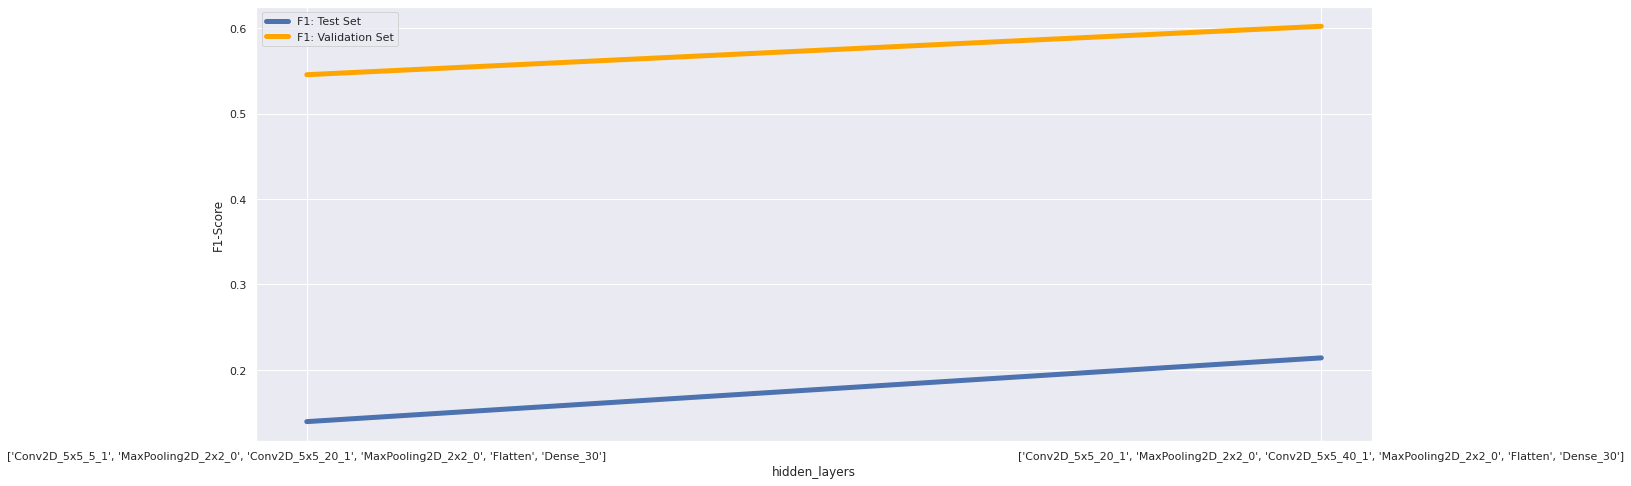

In [ ]:
# No. filters = 5
values_list = [['Conv2D_5x5_5_1','MaxPooling2D_2x2_0','Conv2D_5x5_20_1','MaxPooling2D_2x2_0','Flatten','Dense_30']]

# No. filters = 10
#values_list += [['Conv2D_5x5_10_1','MaxPooling2D_2x2_0','Conv2D_5x5_10_1','MaxPooling2D_2x2_0','Flatten','Dense_30']]

# No. filters = 20
values_list += [['Conv2D_5x5_20_1','MaxPooling2D_2x2_0','Conv2D_5x5_40_1','MaxPooling2D_2x2_0','Flatten','Dense_30']]

model,best_architecture = evaluate_efect_param(parameter_type='model_params',parameter_name='hidden_layers',values_list=values_list)
kfold_params['model_params']['hidden_layers'] = best_architecture

### <font color="blue">Effect Of Pooling type
Finally, let's investigate the effect of the pooling layer. We fix all the other values.

313/313 [==============================] - 4s 12ms/step
Val: ['Conv2D_5x5_20_1', 'MaxPooling2D_2x2_0', 'Conv2D_5x5_20_1', 'MaxPooling2D_2x2_0', 'Flatten', 'Dense_30'], Validation Score: 0.556, Test Score: 0.155
313/313 [==============================] - 8s 25ms/step
Val: ['Conv2D_5x5_20_1', 'AveragePooling2D_2x2_0', 'Conv2D_5x5_20_1', 'AveragePooling2D_2x2_0', 'Flatten', 'Dense_30'], Validation Score: 0.548, Test Score: 0.195


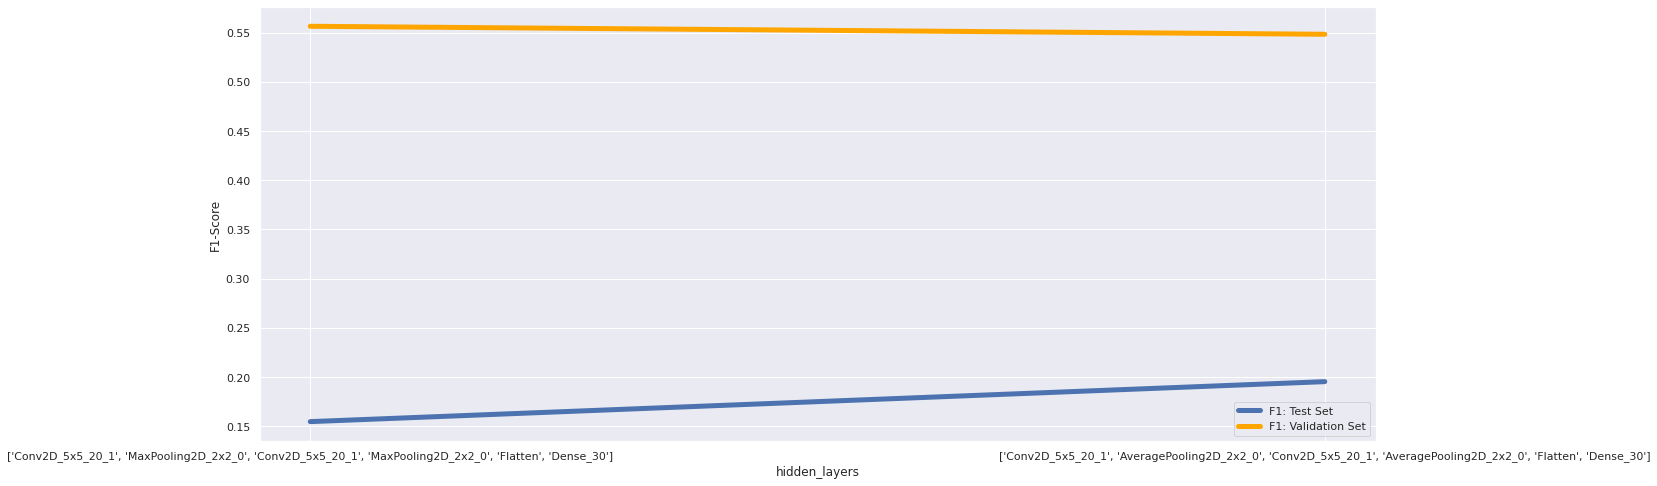

In [ ]:
# MaxPooling with stride 0
values_list = [['Conv2D_5x5_20_1','MaxPooling2D_2x2_0','Conv2D_5x5_20_1','MaxPooling2D_2x2_0','Flatten','Dense_30']]

# AveragePooling with stride 0
values_list += [['Conv2D_5x5_20_1','AveragePooling2D_2x2_0','Conv2D_5x5_20_1','AveragePooling2D_2x2_0','Flatten','Dense_30']]


model,best_architecture = evaluate_efect_param(parameter_type='model_params',parameter_name='hidden_layers',values_list=values_list)
kfold_params['model_params']['hidden_layers'] = best_architecture

# Data Augmentation


### Can you remember what "data augmentation" is and why it is important?
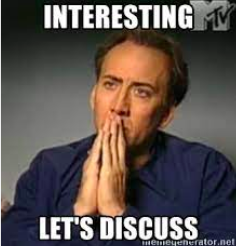






In the lectures, we discussed the idea of expanding our dataset to get better performance, both in training (because of the added data) and in the test sets (because of the added robustness and reduced overfitting). Now is a good time to see how we can do this in practice.

Keras makes this very easy! We can somply import the `ImageDataGenerator` class, and use its features. Let's see and example. The following part is copied directly from [Keras's tutorial here](https://blog.keras.io/building-powerful-image-classification-models-using-very-little-data.html).

In [ ]:
from keras.preprocessing.image import ImageDataGenerator#, array_to_img, img_to_array, load_img

We have several options to create new images from our existing images (brought from [Keras's tutorial here](https://blog.keras.io/building-powerful-image-classification-models-using-very-little-data.html)):


*   `rotation_range`: is a value in degrees (0-180), a range within which to randomly rotate pictures
*   `width_shift` and `height_shift`: are ranges (as a fraction of total width or height) within which to randomly translate pictures vertically or horizontally
*   `rescale`:  is a value by which we will multiply the data before any other processing (similar to the approach we used above to divide all pixels by 255, we could have set `rescale` to 1/255. here).
*   `shear_range`: is for randomly applying shearing transformations
*   `zoom_range`: is for randomly zooming inside pictures
*   `horizontal_flip`: is for randomly flipping half of the images horizontally
*   `fill_mode` is the strategy used for filling in newly created pixels, which can appear after a rotation or a width/height shift.

Let's see how the above image generator works:

In [ ]:
def plot_generated_images(image_generator,no_rows: int=6,no_columns: int=6):
  fig, ax = plt.subplots(nrows=no_rows, ncols=no_rows, figsize=(no_rows,no_columns))
  itr = 0
  for i in range(0,no_rows):
    for j in range(0,no_columns):
      batch = image_generator.next()
      # convert to unsigned integers for viewing
      image = batch[0].astype('uint8')
      #pdb.set_trace()
      # plot image
      ax[i,j].imshow(image)
      ax[i,j].axis('off')

plt.show()

In [ ]:
# Load an image
x = X_train[1,:,:,:]
x = 255*x.reshape((1,) + x.shape)  # this is a Numpy array with shape (1, 32,32,3)

In [ ]:
x.shape

(1, 32, 32, 3)

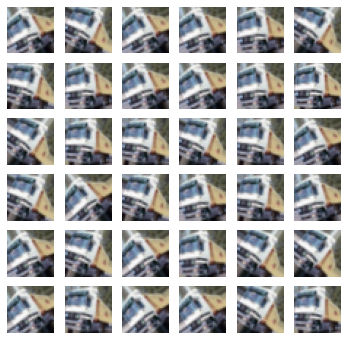

In [ ]:
datagen = ImageDataGenerator(rotation_range=40,fill_mode='nearest')
image_generator = datagen.flow(x, batch_size=1)
plot_generated_images(image_generator)

Let's eplore some other options

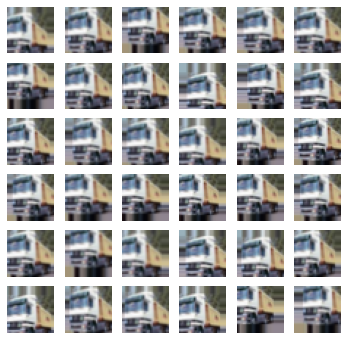

In [ ]:
datagen = ImageDataGenerator(width_shift_range=0.2,height_shift_range=0.2,fill_mode='nearest')
image_generator = datagen.flow(x, batch_size=1)
plot_generated_images(image_generator)

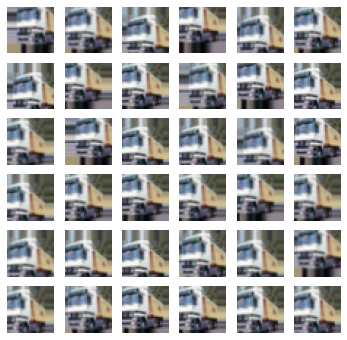

In [ ]:
datagen = ImageDataGenerator(shear_range=0.2,fill_mode='nearest')
it = datagen.flow(x, batch_size=1)
plot_generated_images(image_generator)

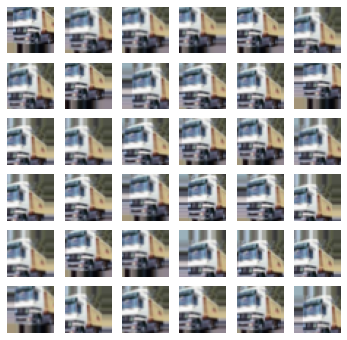

In [ ]:
datagen = ImageDataGenerator(zoom_range=0.2,horizontal_flip=True,fill_mode='nearest')
it = datagen.flow(x, batch_size=1)
plot_generated_images(image_generator)

### Preprocessing
We can achieve preprocessing directly here as well. In our previous approaches, `StandardScaler` made a givne column (attribute) have zero-mean and a standard deviation of 1.

When preporcessing images, our attributes are pixels and making a given pixel have zero mean and a satndard deviation of 1 across all training images is a process called "whitenning" and can be directly accomplished using the `ImageDataGenerator`  class.

First, let's make all pixels have zero mean:

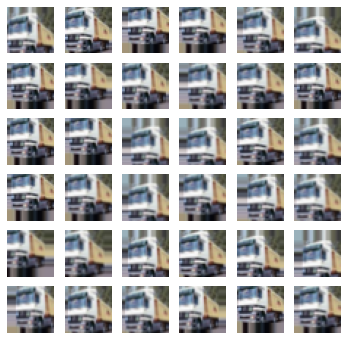

In [ ]:
datagen = ImageDataGenerator(featurewise_center=True)
it = datagen.flow(x, batch_size=1)
plot_generated_images(image_generator)

Now, let's make pixels have a standard deviation of 1:

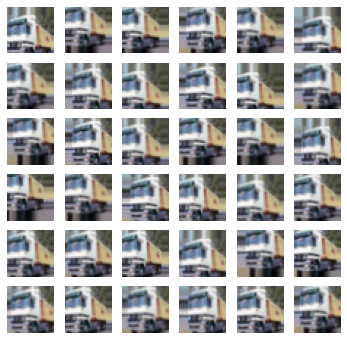

In [ ]:
datagen = ImageDataGenerator(featurewise_std_normalization=True)
it = datagen.flow(x, batch_size=1)
plot_generated_images(image_generator)

### Putting it Altogether
Let's combine all the options and create a complete image generator.

In [ ]:
train_datagen = ImageDataGenerator(
        rotation_range=40,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        featurewise_center=True,
        featurewise_std_normalization=True,
        fill_mode='nearest',
        validation_split=0.2
        )

#test_generator = ImageDataGenerator(rescale=1./255)

In [ ]:
train_iterator = train_datagen.flow(X_train, y_train_enc,subset='training',batch_size=32)
val_iterator = train_datagen.flow(X_train, y_train_enc,subset='validation',batch_size=32)

In [ ]:
history = model.fit_generator(
      train_iterator,
      validation_data=val_iterator,
      callbacks=[early_stopping],
      steps_per_epoch=len(train_iterator),
      validation_steps=len(val_iterator),
      verbose=2,
      epochs=15,
)

Epoch 1/15
1250/1250 - 72s - loss: 1.6334 - accuracy: 0.4099 - val_loss: 1.5953 - val_accuracy: 0.4237 - 72s/epoch - 57ms/step
Epoch 2/15
1250/1250 - 74s - loss: 1.5826 - accuracy: 0.4307 - val_loss: 1.5500 - val_accuracy: 0.4390 - 74s/epoch - 59ms/step
Epoch 3/15
1250/1250 - 70s - loss: 1.5537 - accuracy: 0.4385 - val_loss: 1.5262 - val_accuracy: 0.4463 - 70s/epoch - 56ms/step
Epoch 4/15
1250/1250 - 71s - loss: 1.5338 - accuracy: 0.4478 - val_loss: 1.5386 - val_accuracy: 0.4453 - 71s/epoch - 57ms/step
Epoch 5/15
1250/1250 - 74s - loss: 1.5121 - accuracy: 0.4529 - val_loss: 1.4924 - val_accuracy: 0.4606 - 74s/epoch - 59ms/step
Epoch 6/15
1250/1250 - 71s - loss: 1.4995 - accuracy: 0.4612 - val_loss: 1.4926 - val_accuracy: 0.4638 - 71s/epoch - 57ms/step
Epoch 7/15
1250/1250 - 71s - loss: 1.4763 - accuracy: 0.4673 - val_loss: 1.4664 - val_accuracy: 0.4707 - 71s/epoch - 57ms/step
Epoch 8/15
1250/1250 - 72s - loss: 1.4703 - accuracy: 0.4680 - val_loss: 1.4325 - val_accuracy: 0.4786 - 72s/ep

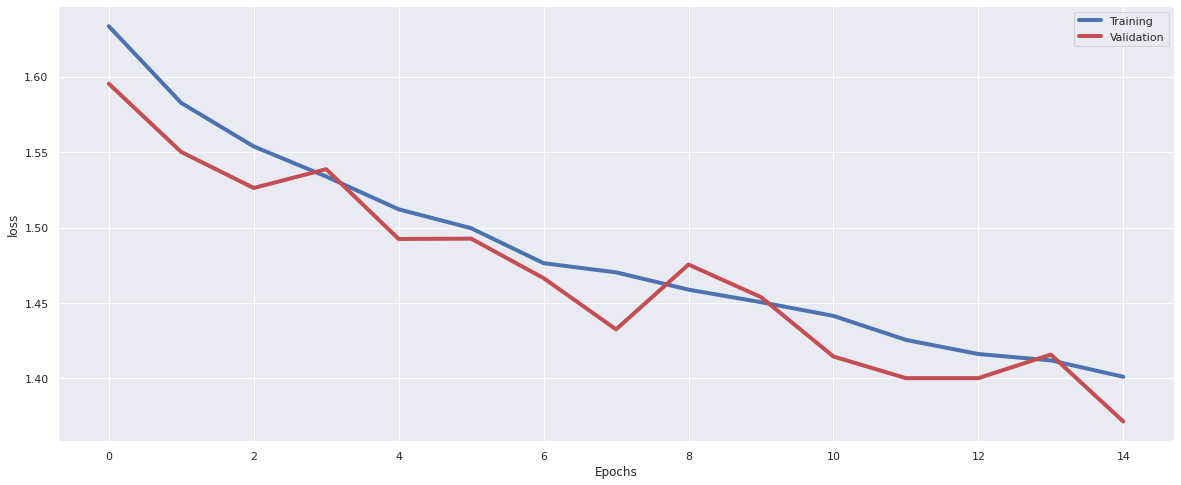

In [ ]:
plot_history(history,plot_type='loss')

In [ ]:
predictions = model.predict(X_test)
print('Weighted F1-score is %.2f' %f1_score(y_test, convert_predictions(predictions), average='weighted'))

313/313 [==============================] - 3s 11ms/step
Weighted F1-score is 0.56


In [ ]:
print('Top-3accuracy %s' % top_k_accuracy_score(y_test, predictions, k=3))

Top-3accuracy 0.858


# Transfer Learning
So far, we have constructed a simple convolutional network, tuned it and improved its performance by exmapnding our dataset using the `ImageDataGenerator` class. Our final model is as strong as its feature extraction capabilities. We spent a considerable time tuing this and other parts of the model.

However, others have performed a similar set of steps and spent much much more time that what have spent so far tuning these feature extracting models. Why not use the fruit of their endeavors, as they have kindly shared them publically? :)


This technique is called **transfer learning** and as usualu, Keras provides a very nice and simple interface to use it in our models.


#### VGG19 Model
Let's start by using the famous VGG19 model

In [ ]:
from tensorflow.keras.applications import VGG19

In [ ]:
def create_transfer_model(base_model,learning_rate=0.001,learning_rate_decay=0.9,no_classes=y_train_enc.shape[1]):
  model = Sequential()
  model.add(base_model)           #Adds the base model
  model.add(Flatten())
  model.add(Dense(128,activation=('relu')))
  model.add(Dropout(.2))
  model.add(Dense(no_classes,activation=('softmax')))

  model.compile(
          loss='categorical_crossentropy',
          optimizer= tf.keras.optimizers.Adam(lr=learning_rate,beta_1=learning_rate_decay),
          metrics=['accuracy'],
          )
  return model


In [ ]:
base_model = VGG19(
    include_top=False,    # We do not include the top, because we just need the feature extraction layers
    weights='imagenet',
    input_shape=X_train.shape[1:],
    classes=y_train_enc.shape[1])

# We make the weight non-trainable to reduce the number of weights in the network
for layer in base_model.layers:
    layer.trainable = False

80134624/80134624 [==============================] - 3s 0us/step


In [ ]:
model = create_transfer_model(base_model)
model.summary()

Model: "sequential_27"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg19 (Functional)          (None, 1, 1, 512)         20024384  
                                                                 
 flatten_27 (Flatten)        (None, 512)               0         
                                                                 
 dense_54 (Dense)            (None, 128)               65664     
                                                                 
 dropout_27 (Dropout)        (None, 128)               0         
                                                                 
 dense_55 (Dense)            (None, 10)                1290      
                                                                 
Total params: 20,091,338
Trainable params: 66,954
Non-trainable params: 20,024,384
_________________________________________________________________


Now that we have the base model, let's train it and see what performance we get by training the last few layers.

In [ ]:
history = model.fit_generator(
      train_iterator,
      validation_data=val_iterator,
      callbacks=[early_stopping],
      steps_per_epoch=len(train_iterator),
      validation_steps=len(val_iterator),
      verbose=1,
      epochs=10,
)

Epoch 1/10
1250/1250 [==============================] - 694s 554ms/step - loss: 1.7415 - accuracy: 0.3775 - val_loss: 1.5942 - val_accuracy: 0.4360
Epoch 2/10
1250/1250 [==============================] - 701s 561ms/step - loss: 1.6029 - accuracy: 0.4283 - val_loss: 1.5389 - val_accuracy: 0.4531
Epoch 3/10
1250/1250 [==============================] - 709s 567ms/step - loss: 1.5632 - accuracy: 0.4432 - val_loss: 1.5082 - val_accuracy: 0.4647
Epoch 4/10
1250/1250 [==============================] - 717s 574ms/step - loss: 1.5419 - accuracy: 0.4504 - val_loss: 1.4917 - val_accuracy: 0.4731
Epoch 5/10
1250/1250 [==============================] - 704s 563ms/step - loss: 1.5242 - accuracy: 0.4571 - val_loss: 1.4808 - val_accuracy: 0.4780
Epoch 6/10
1250/1250 [==============================] - 708s 567ms/step - loss: 1.5123 - accuracy: 0.4637 - val_loss: 1.4760 - val_accuracy: 0.4742
Epoch 7/10
1250/1250 [==============================] - 711s 569ms/step - loss: 1.5028 - accuracy: 0.4619 - val_

In [ ]:
predictions = model.predict(X_test)
print('Weighted F1-score is %.2f' %f1_score(y_test, convert_predictions(predictions), average='weighted'))

313/313 [==============================] - 138s 441ms/step
Weighted F1-score is 0.52


In [ ]:
print('Top-3accuracy %s' % top_k_accuracy_score(y_test, predictions, k=3))

Top-3accuracy 0.8313


In [ ]:
import copy
model_vgg = copy.deepcopy(model)

#### ResNet Model
Next, we try the well know ResNet50 model. The steps are basically the same as above, except for the base model.

In [ ]:
from keras.applications import resnet

base_model = resnet.ResNet50(
    include_top=False,    # We do not include the top, because we just need the feature extraction layers
    weights='imagenet',
    input_shape=X_train.shape[1:],
    classes=y_train_enc.shape[1])

# We make the weight non-trainable to reduce the number of weights in the network
for layer in base_model.layers:
    layer.trainable = False

In [ ]:
model = create_transfer_model(base_model)
model.summary()

Model: "sequential_28"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50 (Functional)       (None, 1, 1, 2048)        23587712  
                                                                 
 flatten_28 (Flatten)        (None, 2048)              0         
                                                                 
 dense_56 (Dense)            (None, 128)               262272    
                                                                 
 dropout_28 (Dropout)        (None, 128)               0         
                                                                 
 dense_57 (Dense)            (None, 10)                1290      
                                                                 
Total params: 23,851,274
Trainable params: 263,562
Non-trainable params: 23,587,712
_________________________________________________________________


In [ ]:
history = model.fit_generator(
      train_iterator,
      validation_data=val_iterator,
      callbacks=[early_stopping],
      steps_per_epoch=len(train_iterator),
      validation_steps=len(val_iterator),
      verbose=1,
      epochs=20,
)

Epoch 1/20
1250/1250 [==============================] - 251s 198ms/step - loss: 2.3115 - accuracy: 0.1007 - val_loss: 2.3028 - val_accuracy: 0.0979
Epoch 2/20
1250/1250 [==============================] - 244s 195ms/step - loss: 2.3028 - accuracy: 0.0992 - val_loss: 2.3029 - val_accuracy: 0.0999
Epoch 3/20
1250/1250 [==============================] - 244s 195ms/step - loss: 2.3029 - accuracy: 0.0992 - val_loss: 2.3029 - val_accuracy: 0.0937
Epoch 4/20
1250/1250 [==============================] - 245s 196ms/step - loss: 2.3028 - accuracy: 0.1006 - val_loss: 2.3029 - val_accuracy: 0.0981
Epoch 5/20
1250/1250 [==============================] - 247s 198ms/step - loss: 2.3027 - accuracy: 0.1017 - val_loss: 2.3029 - val_accuracy: 0.0937
Epoch 6/20
1250/1250 [==============================] - 248s 199ms/step - loss: 2.3028 - accuracy: 0.0982 - val_loss: 2.3030 - val_accuracy: 0.0937


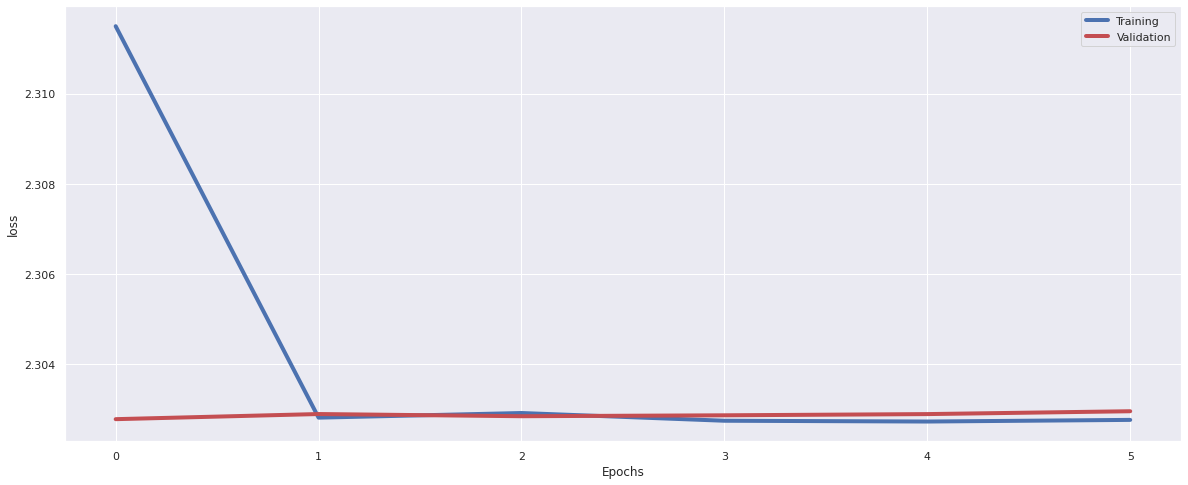

In [ ]:
plot_history(history,plot_type='loss')

In [ ]:
predictions = model.predict(X_test)
print('Weighted F1-score is %.2f' %f1_score(y_test, convert_predictions(predictions), average='weighted'))

313/313 [==============================] - 44s 139ms/step
Weighted F1-score is 0.02


In [ ]:
print('Top-3accuracy %s' % top_k_accuracy_score(y_test, predictions, k=3))

Top-3accuracy 0.2988


Looks like the ResNet50 model needs some tuning for this task, or maybe a lot more iterations to learn.

### Last Performance Check
The last model should be our best model so far. So let's see how the confusion matrix and performance looks like.

313/313 [==============================] - 136s 433ms/step
Weighted F1-score is 0.52


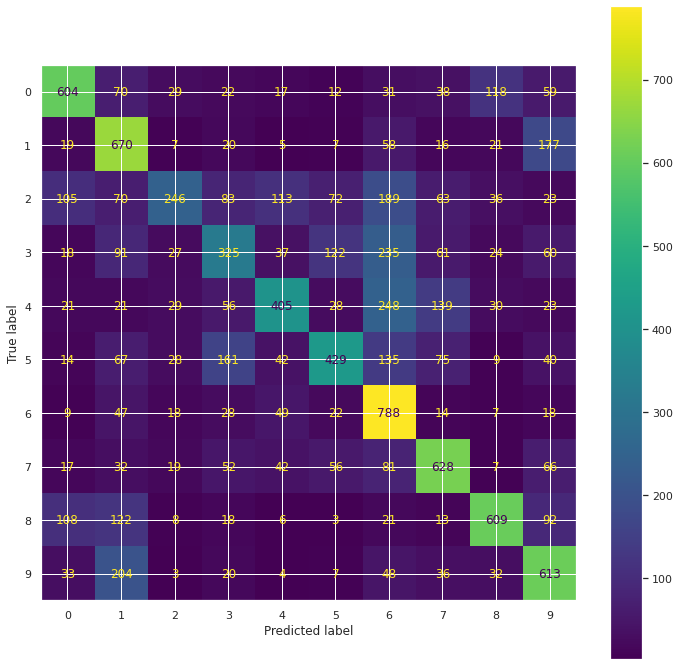

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
predictions = model_vgg.predict(X_test)
print('Weighted F1-score is %.2f' %f1_score(y_test, convert_predictions(predictions), average='weighted'))
fig, ax = plt.subplots(figsize=(12, 12))
ConfusionMatrixDisplay.from_predictions(y_test, convert_predictions(predictions),ax=ax)
plt.show()

In [ ]:
print('Top-3accuracy %s' % top_k_accuracy_score(y_test, predictions, k=3))

Top-3accuracy 0.8313


313/313 [==============================] - 47s 151ms/step
Weighted F1-score is 0.02


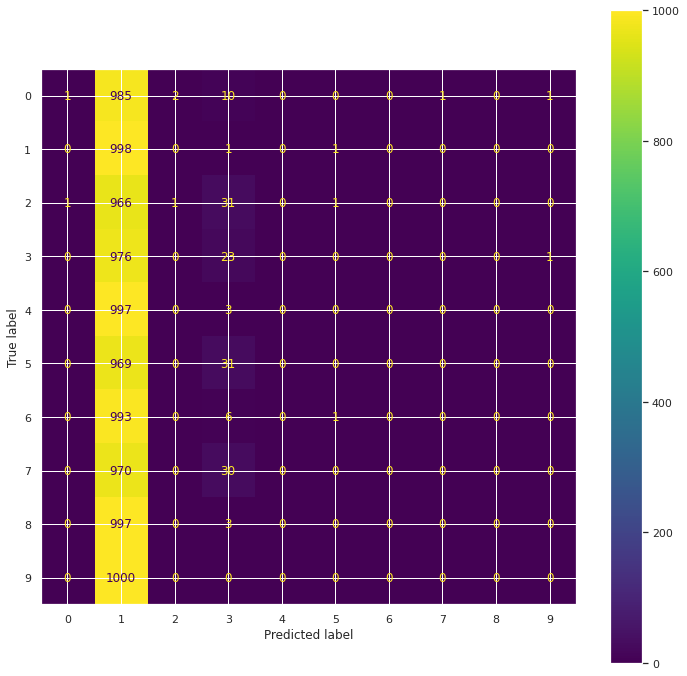

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
predictions = model.predict(X_test)
print('Weighted F1-score is %.2f' %f1_score(y_test, convert_predictions(predictions), average='weighted'))
fig, ax = plt.subplots(figsize=(12, 12))
ConfusionMatrixDisplay.from_predictions(y_test, convert_predictions(predictions),ax=ax)
plt.show()

In [ ]:
print('Top-3accuracy %s' % top_k_accuracy_score(y_test, predictions, k=3))

Top-3accuracy 0.2988


Any Final Thoughts?

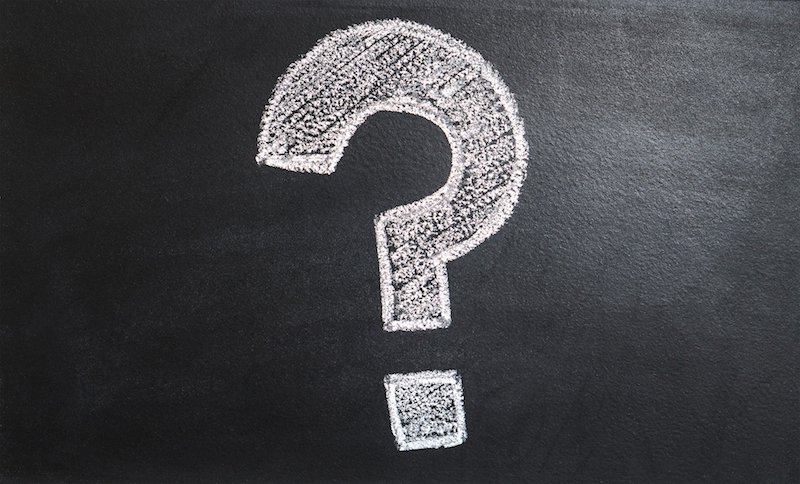

# Don't Forget the Survey!
Please help us improve the quality of the lab sessions by filling this [short suvery](https://forms.gle/ENJsCbDR14hDsmPx6) about today's session.


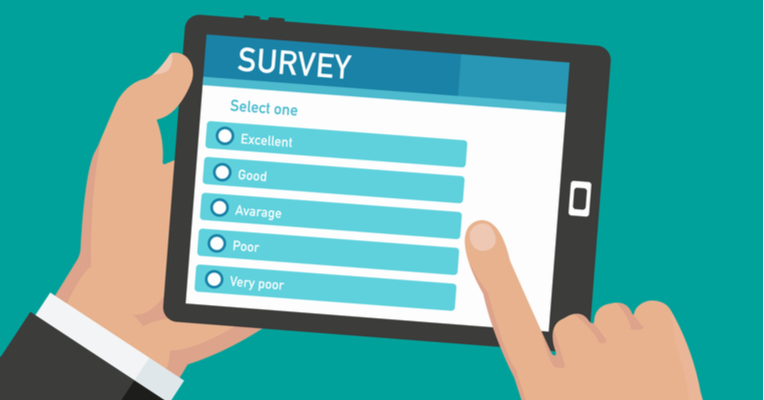